# 03 — Nettoyage & Preprocessing

**Objectif** : Préparer les données pour le ML — sans data leakage.

**Pipeline** :  
`data_raw.csv` → nettoyage → encodage → split → pipeline sklearn → `data_prepared/`

**Cible ML** : Classification qualité radio basée sur `rscp_active_1` (RSCP de la cellule active principale)  
- Bonne qualité : RSCP ≥ -85 dBm  
- Mauvaise qualité : RSCP < -85 dBm

In [1]:
RUN_INSTALL = False
if RUN_INSTALL:
    import subprocess, sys
    pkgs = ["pandas", "numpy", "matplotlib", "seaborn", "scikit-learn", "joblib"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs)

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42

NOTEBOOK_DIR = Path().resolve()
DATA_DIR     = NOTEBOOK_DIR / "data"
PREP_DIR     = DATA_DIR / "data_prepared"
PREP_DIR.mkdir(parents=True, exist_ok=True)

IN_FILE      = DATA_DIR / "data_raw.csv"
print(f"Lecture  : {IN_FILE}")
print(f"Sortie   : {PREP_DIR}")
print(f"sklearn  : ok")

Lecture  : C:\projet ingeneurie des réseaux\notebooks\data\data_raw.csv
Sortie   : C:\projet ingeneurie des réseaux\notebooks\data\data_prepared
sklearn  : ok


## 2. Chargement

In [3]:
df = pd.read_csv(IN_FILE, low_memory=False)
print(f"Shape brut : {df.shape}")
df.head(3)

Shape brut : (8332, 85)


,time,band,channel_1,channel_2,channel_3,channel_4,channel_5,channel_n_vals,channel_present,sc_active_1,sc_active_2,sc_active_3,sc_active_4,sc_active_5,sc_active_n_vals,sc_active_present,rscp_active_1,rscp_active_2,rscp_active_3,rscp_active_4,rscp_active_5,rscp_active_n_vals,rscp_active_present,ecno_active_1,ecno_active_2,ecno_active_3,ecno_active_4,ecno_active_5,ecno_active_n_vals,ecno_active_present,rscp_detected_1,sc_detected_1,sc_detected_2,sc_detected_3,sc_detected_4,sc_detected_5,sc_detected_6,sc_detected_7,sc_detected_8,sc_detected_9,...,sc_detected_15,sc_detected_16,sc_detected_17,sc_detected_18,sc_detected_19,sc_detected_20,sc_detected_21,sc_detected_22,sc_detected_23,sc_detected_24,sc_detected_25,sc_detected_26,sc_detected_27,sc_detected_28,sc_detected_29,sc_detected_30,sc_detected_31,sc_detected_32,sc_detected_33,sc_detected_34,sc_detected_35,sc_detected_36,sc_detected_37,sc_detected_38,sc_detected_39,sc_detected_40,sc_detected_41,rscp_active_mean,rscp_active_max,rscp_active_min,rscp_active_std,rscp_active_range,ecno_active_mean,ecno_active_max,ecno_active_min,ecno_active_std,rscp_detected_mean,rscp_detected_max,rscp_detected_min,rscp_delta_active_vs_best_detected
0,8:36:11.915,UMTS FDD 2100 band 1,10738.0,NaN,NaN,NaN,NaN,1,1,387.0,NaN,NaN,NaN,NaN,1,1,-73.2,NaN,NaN,NaN,NaN,1,1,-9.9,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-73.2,-73.2,-73.2,NaN,0.0,-9.9,-9.9,-9.9,NaN,NaN,NaN,NaN,NaN
1,8:36:12.338,UMTS FDD 2100 band 1,10738.0,NaN,NaN,NaN,NaN,1,1,387.0,NaN,NaN,NaN,NaN,1,1,-78.1,NaN,NaN,NaN,NaN,1,1,-14.3,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-78.1,-78.1,-78.1,NaN,0.0,-14.3,-14.3,-14.3,NaN,NaN,NaN,NaN,NaN
2,8:36:13.021,UMTS FDD 2100 band 1,10738.0,NaN,NaN,NaN,NaN,1,1,387.0,NaN,NaN,NaN,NaN,1,1,-74.3,NaN,NaN,NaN,NaN,1,1,-10.6,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-74.3,-74.3,-74.3,NaN,0.0,-10.6,-10.6,-10.6,NaN,NaN,NaN,NaN,NaN


## 3. Conversion numérique des colonnes utiles

In [4]:
# Colonnes numériques candidates (toutes les _1, _2, ..., features dérivées)
num_candidates = [
    c for c in df.columns
    if any(c.startswith(p) for p in [
        "channel_", "sc_active_", "rscp_active_",
        "ecno_active_", "rscp_detected_", "sc_detected_",
        "n_cells_ratio", "rscp_delta"
    ])
]

print(f"Colonnes numériques candidates : {len(num_candidates)}")
for c in df[num_candidates].columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Colonne band : catégorielle
if "band" in df.columns:
    df["band"] = df["band"].astype(str).str.strip()

print("✅ Conversion numérique effectuée")
print(df[num_candidates[:6]].dtypes)

Colonnes numériques candidates : 83
✅ Conversion numérique effectuée
channel_1         float64
channel_2         float64
channel_3         float64
channel_4         float64
channel_5         float64
channel_n_vals      int64
dtype: object


## 4. Création de la variable cible

On utilise le RSCP de la cellule active principale (`rscp_active_1`) comme base.  
Seuil standard UMTS : **-85 dBm** (en dessous = mauvaise qualité).

Colonne RSCP utilisée pour la cible : 'rscp_active_1'
Seuil : -85.0 dBm

Lignes supprimées (RSCP NaN) : 10 (0.1%)
Lignes restantes : 8,322

── Distribution cible ──
  Bonne qualité  (1) :   5430 (65.2%)
  Mauvaise qualité(0):   2892 (34.8%)


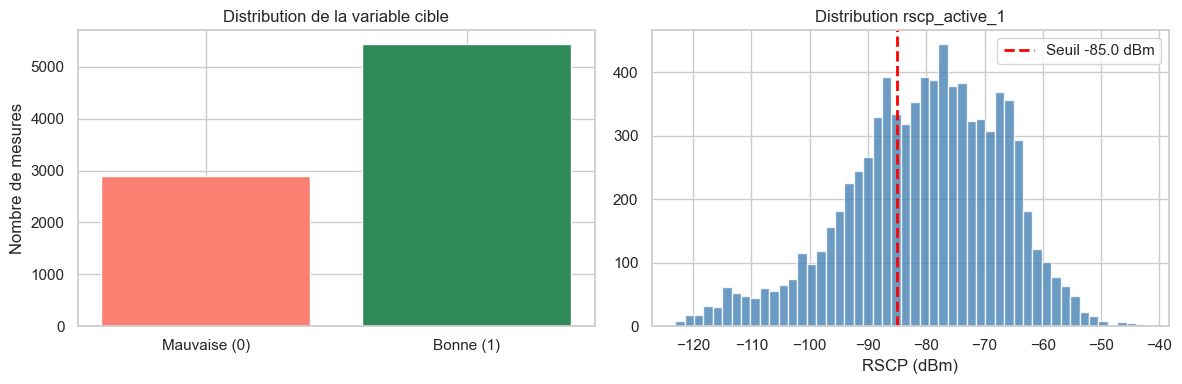

In [5]:
RSCP_THRESHOLD = -85.0  # dBm

# Chercher la colonne RSCP principale
rscp_col = None
for candidate in ["rscp_active_1", "rscp_active_mean"]:
    if candidate in df.columns:
        rscp_col = candidate
        break

if rscp_col is None:
    raise ValueError("❌ Aucune colonne RSCP actif trouvée — vérifier le notebook 02")

print(f"Colonne RSCP utilisée pour la cible : '{rscp_col}'")
print(f"Seuil : {RSCP_THRESHOLD} dBm")

# Cible binaire : 1 = bonne qualité, 0 = mauvaise qualité
df["target"] = (df[rscp_col] >= RSCP_THRESHOLD).astype(int)

# Lignes sans RSCP → pas de cible → on les retire MAINTENANT (avant split)
n_before = len(df)
df = df.dropna(subset=[rscp_col]).reset_index(drop=True)
n_after = len(df)
print(f"\nLignes supprimées (RSCP NaN) : {n_before - n_after} ({(n_before-n_after)/n_before*100:.1f}%)")
print(f"Lignes restantes : {n_after:,}")

# Distribution de la cible
vc = df["target"].value_counts()
print(f"\n── Distribution cible ──")
print(f"  Bonne qualité  (1) : {vc.get(1, 0):>6} ({vc.get(1,0)/n_after*100:.1f}%)")
print(f"  Mauvaise qualité(0): {vc.get(0, 0):>6} ({vc.get(0,0)/n_after*100:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Mauvaise (0)", "Bonne (1)"], [vc.get(0,0), vc.get(1,0)],
            color=["salmon", "seagreen"], edgecolor="white")
axes[0].set_title("Distribution de la variable cible")
axes[0].set_ylabel("Nombre de mesures")

data_rscp = df[rscp_col].dropna()
axes[1].hist(data_rscp, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(RSCP_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Seuil {RSCP_THRESHOLD} dBm")
axes[1].set_title(f"Distribution {rscp_col}")
axes[1].set_xlabel("RSCP (dBm)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Sélection des features

In [6]:
# On exclut la cible, la colonne time, et les colonnes _raw
EXCLUDE = {"target", "time", rscp_col}  # rscp_col est la source de la cible → exclure pour éviter leakage

# Features numériques : colonnes positionnelles + features dérivées
NUM_FEATURES = [
    c for c in df.columns
    if c not in EXCLUDE
    and df[c].dtype in ["float64", "float32", "int64", "int32"]
    and not c.endswith("_raw")
]

# Features catégorielles
CAT_FEATURES = [
    c for c in df.columns
    if c not in EXCLUDE
    and df[c].dtype == "object"
    and c != "time"
]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

print(f"Features numériques  : {len(NUM_FEATURES)}")
print(f"Features catégorielles: {len(CAT_FEATURES)}")
print(f"Total features        : {len(ALL_FEATURES)}")
print(f"\n── Numériques ──\n{NUM_FEATURES}")
print(f"\n── Catégorielles ──\n{CAT_FEATURES}")

Features numériques  : 82
Features catégorielles: 0
Total features        : 82

── Numériques ──
['channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_n_vals', 'channel_present', 'sc_active_1', 'sc_active_2', 'sc_active_3', 'sc_active_4', 'sc_active_5', 'sc_active_n_vals', 'sc_active_present', 'rscp_active_2', 'rscp_active_3', 'rscp_active_4', 'rscp_active_5', 'rscp_active_n_vals', 'rscp_active_present', 'ecno_active_1', 'ecno_active_2', 'ecno_active_3', 'ecno_active_4', 'ecno_active_5', 'ecno_active_n_vals', 'ecno_active_present', 'rscp_detected_1', 'sc_detected_1', 'sc_detected_2', 'sc_detected_3', 'sc_detected_4', 'sc_detected_5', 'sc_detected_6', 'sc_detected_7', 'sc_detected_8', 'sc_detected_9', 'sc_detected_10', 'sc_detected_11', 'sc_detected_12', 'sc_detected_13', 'sc_detected_14', 'sc_detected_15', 'sc_detected_16', 'sc_detected_17', 'sc_detected_18', 'sc_detected_19', 'sc_detected_20', 'sc_detected_21', 'sc_detected_22', 'sc_detected_23', 'sc_detected_24',

## 6. Analyse des valeurs manquantes (avant imputation)

In [ ]:
miss = df[ALL_FEATURES].isnull().mean() * 100
miss = miss[miss > 0].sort_values(ascending=False)

print(f"Colonnes avec NaN : {len(miss)} / {len(ALL_FEATURES)}")
if not miss.empty:
    print(miss.to_string())
    
    # Colonnes avec trop de NaN → supprimer
    HIGH_MISS_THRESHOLD = 80  # %
    cols_to_drop = miss[miss > HIGH_MISS_THRESHOLD].index.tolist()
    if cols_to_drop:
        print(f"\n  Colonnes supprimées (>{HIGH_MISS_THRESHOLD}% NaN) : {cols_to_drop}")
        NUM_FEATURES = [c for c in NUM_FEATURES if c not in cols_to_drop]
        CAT_FEATURES = [c for c in CAT_FEATURES if c not in cols_to_drop]
        ALL_FEATURES = NUM_FEATURES + CAT_FEATURES
else:
    print(" Pas de NaN dans les features sélectionnées")

Colonnes avec NaN : 68 / 82
sc_detected_41                        99.987984
sc_detected_40                        99.963951
sc_detected_39                        99.939918
sc_detected_38                        99.939918
sc_detected_37                        99.903869
sc_detected_36                        99.891853
sc_detected_35                        99.855804
sc_detected_34                        99.855804
sc_detected_33                        99.831771
sc_detected_32                        99.771689
sc_detected_31                        99.699591
channel_5                             99.459265
ecno_active_5                         99.459265
rscp_active_5                         99.459265
sc_active_5                           99.459265
sc_detected_30                        99.447248
sc_detected_29                        99.086758
sc_detected_28                        98.834415
sc_detected_27                        98.546023
sc_detected_26                        98.041336
sc_detected_

## 7. Split Train / Validation / Test

**Stratégie** : 70% train, 15% validation, 15% test — split stratifié sur la cible.  
⚠️ On fit le preprocessing **uniquement sur le train** (pas de leakage).

In [8]:
X = df[ALL_FEATURES].copy()
y = df["target"].copy()

# Split 70 / 30
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Split 30 → 15 / 15
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print("── Tailles des splits ──")
print(f"  Train      : {len(X_train):>6} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation : {len(X_val):>6} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test       : {len(X_test):>6} ({len(X_test)/len(X)*100:.1f}%)")

print("\n── Distribution cible par split ──")
for name, y_s in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    pct = y_s.mean() * 100
    print(f"  {name:<10} : {pct:.1f}% classe 1 (bonne qualité)")

── Tailles des splits ──
  Train      :   5825 (70.0%)
  Validation :   1248 (15.0%)
  Test       :   1249 (15.0%)

── Distribution cible par split ──
  Train      : 65.3% classe 1 (bonne qualité)
  Val        : 65.2% classe 1 (bonne qualité)
  Test       : 65.3% classe 1 (bonne qualité)


## 8. Pipeline de preprocessing sklearn

In [ ]:
# ── Pipeline numériques : imputation médiane + standardisation ────────────────
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # médiane robuste aux outliers
    ("scaler",  StandardScaler()),
])

# ── Pipeline catégorielles : imputation mode + OHE ───────────────────────────
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# ── Assemblage ────────────────────────────────────────────────────────────────
transformers = []
if NUM_FEATURES:
    transformers.append(("num", num_pipeline, NUM_FEATURES))
if CAT_FEATURES:
    transformers.append(("cat", cat_pipeline, CAT_FEATURES))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    verbose_feature_names_out=False,
)

print(" Preprocessor défini")
print(preprocessor)

✅ Preprocessor défini
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['channel_1', 'channel_2', 'channel_3',
                                  'channel_n_vals', 'channel_present',
                                  'sc_active_1', 'sc_active_2', 'sc_active_3',
                                  'sc_active_n_vals', 'sc_active_present',
                                  'rscp_active_2', 'rscp_active_3',
                                  'rscp_active_n_vals', 'rscp_active_present',
                                  'ecno_active_1', 'ecno_active_2',
                                  'ecno_active_3', 'ecno_active_n_vals',
                                  'ecno_active_present', 'sc_detected_1',
                                  'sc_detected_2', 

In [ ]:
# ── Fit sur le TRAIN uniquement — pas de leakage ──────────────────────────────
print("Fitting preprocessor sur le train...")
X_train_prep = preprocessor.fit_transform(X_train)

# Transform val & test
X_val_prep   = preprocessor.transform(X_val)
X_test_prep  = preprocessor.transform(X_test)

# Récupérer les noms de features après transformation
try:
    feature_names_out = preprocessor.get_feature_names_out().tolist()
except Exception:
    feature_names_out = [f"f_{i}" for i in range(X_train_prep.shape[1])]

print(f" Preprocessing terminé")
print(f"   Shape X_train_prep : {X_train_prep.shape}")
print(f"   Shape X_val_prep   : {X_val_prep.shape}")
print(f"   Shape X_test_prep  : {X_test_prep.shape}")
print(f"   Features output    : {len(feature_names_out)}")

Fitting preprocessor sur le train...
✅ Preprocessing terminé
   Shape X_train_prep : (5825, 37)
   Shape X_val_prep   : (1248, 37)
   Shape X_test_prep  : (1249, 37)
   Features output    : 37


## 9. Sauvegarde

In [ ]:
# Sauvegarder les arrays numpy
np.save(PREP_DIR / "X_train.npy", X_train_prep)
np.save(PREP_DIR / "X_val.npy",   X_val_prep)
np.save(PREP_DIR / "X_test.npy",  X_test_prep)
np.save(PREP_DIR / "y_train.npy", y_train.values)
np.save(PREP_DIR / "y_val.npy",   y_val.values)
np.save(PREP_DIR / "y_test.npy",  y_test.values)

# Sauvegarder le preprocessor
joblib.dump(preprocessor, PREP_DIR / "preprocessor.pkl")

# Sauvegarder les noms de features
pd.Series(feature_names_out).to_csv(PREP_DIR / "feature_names.csv", index=False, header=["feature"])

# Sauvegarder les métadonnées
meta = {
    "n_train": len(y_train),
    "n_val": len(y_val),
    "n_test": len(y_test),
    "n_features": len(feature_names_out),
    "rscp_threshold": RSCP_THRESHOLD,
    "target_col": "target",
    "rscp_source_col": rscp_col,
    "num_features": NUM_FEATURES,
    "cat_features": CAT_FEATURES,
}
import json
with open(PREP_DIR / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(" Fichiers sauvegardés :")
for f in sorted(PREP_DIR.iterdir()):
    size = f.stat().st_size
    print(f"   {f.name:<30} {size/1024:>8.1f} KB")

✅ Fichiers sauvegardés :
   feature_names.csv                   0.6 KB
   metadata.json                       1.0 KB
   preprocessor.pkl                    5.0 KB
   X_test.npy                        361.2 KB
   X_train.npy                      1683.9 KB
   X_val.npy                         360.9 KB
   y_test.npy                          9.9 KB
   y_train.npy                        45.6 KB
   y_val.npy                           9.9 KB


## 10. Checks de validation

In [ ]:
# Recharger et vérifier
X_train_check = np.load(PREP_DIR / "X_train.npy")
y_train_check = np.load(PREP_DIR / "y_train.npy")
prep_check    = joblib.load(PREP_DIR / "preprocessor.pkl")

assert X_train_check.shape == X_train_prep.shape, " Shape X_train incohérent après rechargement"
assert len(y_train_check) == len(y_train), " Taille y_train incohérente"
assert X_train_prep.shape[0] == len(y_train), " X et y train désalignés"
assert X_val_prep.shape[0] == len(y_val), " X et y val désalignés"
assert X_test_prep.shape[0] == len(y_test), " X et y test désalignés"
assert X_train_prep.shape[1] == X_val_prep.shape[1] == X_test_prep.shape[1], \
    " Nb de features incohérent entre splits"

# Pas de NaN dans les données preprocessées
assert not np.isnan(X_train_prep).any(), " NaN dans X_train_prep"
assert not np.isnan(X_val_prep).any(),   " NaN dans X_val_prep"
assert not np.isnan(X_test_prep).any(),  " NaN dans X_test_prep"

# Vérification no-leakage : le scaler a été fit sur train uniquement
# Mean du train preprocessé ≈ 0 (StandardScaler)
train_means = np.abs(X_train_prep.mean(axis=0))
assert train_means.mean() < 0.1, "  Moyenne non nulle — vérifier StandardScaler"

print(f" Toutes assertions passées")
print(f"   Train  : {X_train_prep.shape}  |  y: {np.bincount(y_train_check.astype(int))}")
print(f"   Val    : {X_val_prep.shape}  |  y: {np.bincount(y_val.values.astype(int))}")
print(f"   Test   : {X_test_prep.shape}  |  y: {np.bincount(y_test.values.astype(int))}")
print(f"   NaN    : aucun ")
print("\n Prochaine étape : 04_modelisation_entrainement.ipynb")

✅ Toutes assertions passées
   Train  : (5825, 37)  |  y: [2024 3801]
   Val    : (1248, 37)  |  y: [434 814]
   Test   : (1249, 37)  |  y: [434 815]
   NaN    : aucun ✅

📌 Prochaine étape : 04_modelisation_entrainement.ipynb
